<a href="https://colab.research.google.com/github/Leo05-u/EMSC_Wk7_P1/blob/main/EMSC2010_W7_P1_NB1_u7447903.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W7-P1-NB1

We will test if the air pressures inside and outside the building are the same.

The whole class will collect data using Phyphox (see the *Pressure* option), with each person measuring one inside pressure and one outside pressure. These data will be our measured air pressure samples.

Use the ```PyMC``` code we developed in the previous session (see notebook ```EMSC2010-W7-L1-NB3``` to estimate the posterior distributions for the mean atmospheric pressures inside and outside the building.

In [ ]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
Data_in = np.array([965.784, 965.070, 965.500, 965.993, 965.765, 965.786, 955.604, 965.057, 965.500, 965.390, 965.302, 965.910, 963.623, 965.388, 965.500, 965.910, 965.564, 965.893, 965.735, 965.537]) #pressure inside
Data_out = np.array([966.176, 965.453, 966.250, 966.363, 966.150, 966.085, 965.649, 965.414, 966.172, 965.750, 965.673, 966.257, 964.034, 965.763, 965.850, 966.264, 966.111, 965.864, 966.291, 965.867]) #Pressure outside

Output()

<Axes: title={'center': 'mu'}>

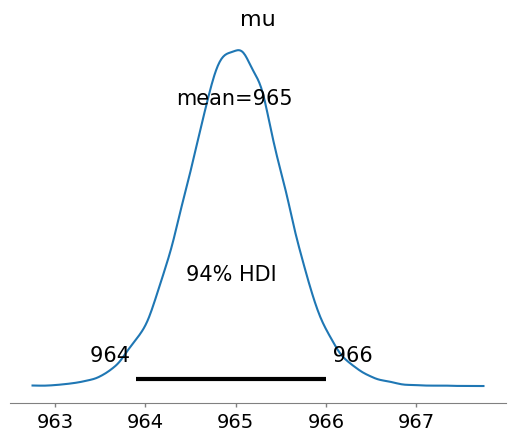

In [ ]:
with pm.Model() as inside_model:

    # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
    mu = pm.Normal("mu", mu=1000, sigma=100)

    # Prior for std of inside — HalfNormal with a standard deviation of 20.
    sigma = pm.HalfNormal("sigma", sigma=20)

    # Likelihood given the data
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=Data_in)

    # Obtain 20,000 samples from the posterior
    trace_in = pm.sample(20000, tune=2000, return_inferencedata=True)

#plot the posterior distribution for the mean
az.plot_posterior(trace_in, var_names=["mu"])

Output()

<Axes: title={'center': 'mu'}>

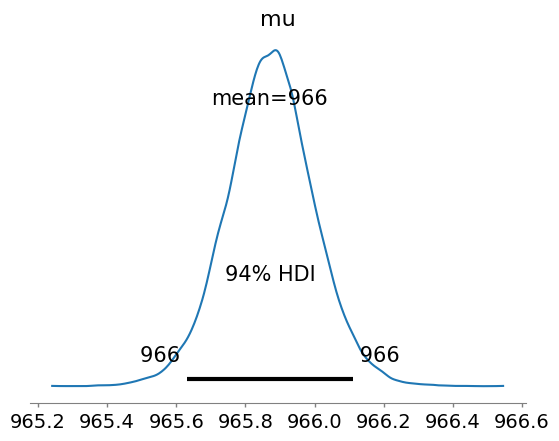

In [ ]:
with pm.Model() as outside_model:

    # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
    mu = pm.Normal("mu", mu=1000, sigma=100)

    # Prior for std of inside — HalfNormal with a standard deviation of 20.
    sigma = pm.HalfNormal("sigma", sigma=20)

    # Likelihood given the data
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=Data_out)

    # Obtain 20,000 samples from the posterior
    trace_out = pm.sample(20000, tune=2000, return_inferencedata=True)

#plot the posterior distribution for the mean
az.plot_posterior(trace_out, var_names=["mu"])

In [ ]:
# Extract the posterior samples as a numpy array
mu_samples_in = trace_in.posterior["mu"].values.flatten()
mu_samples_out = trace_out.posterior["mu"].values.flatten()

Text(0.5, 0, 'Pressure difference inside-outside [hPa]')

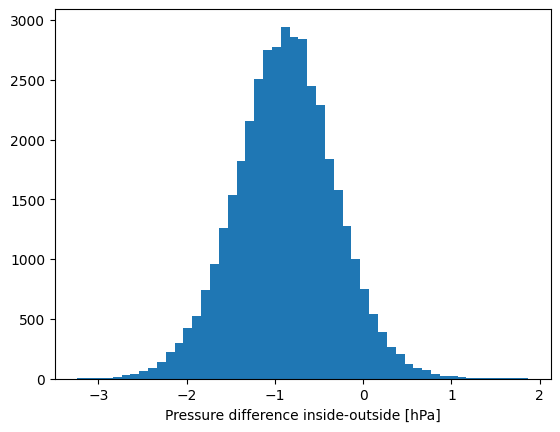

In [ ]:
mu_diff = mu_samples_in - mu_samples_out
plt.hist(mu_diff, bins=51)
plt.xlabel('Pressure difference inside-outside [hPa]')

In [ ]:
az.hdi(mu_diff, hdi_prob = 0.95)

array([-2.00789942,  0.22908621])